# Simple Linear Regression: CGPA vs Placement Package
Predicting placement package (in LPA) of students based on their CGPA using Simple Linear Regression.

**Dataset:** `placement_data.csv` (200 students)
- `CGPA` — independent variable (X)
- `Placement_Package_LPA` — dependent variable (y)

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

plt.style.use('seaborn-v0_8-darkgrid')

## 1. Load the Dataset

In [13]:
df = pd.read_csv('/Users/nikhilbishnoi/Desktop/python/placement_data.csv/placement_data.csv')
print(df.shape)
df.head()

(200, 2)


,CGPA,Placement_Package_LPA
0,6.87,9.06
1,9.75,13.43
2,8.66,12.19
3,7.99,10.37
4,5.78,10.30


In [4]:
df.describe()

,CGPA,Placement_Package_LPA
count,200.000000,200.000000
mean,7.420050,10.471450
std,1.474724,1.997286
min,5.030000,6.000000
25%,6.140000,8.720000
50%,7.475000,10.455000
75%,8.785000,12.195000
max,9.930000,14.690000


## 2. Visualize Raw Data (Scatter Plot)

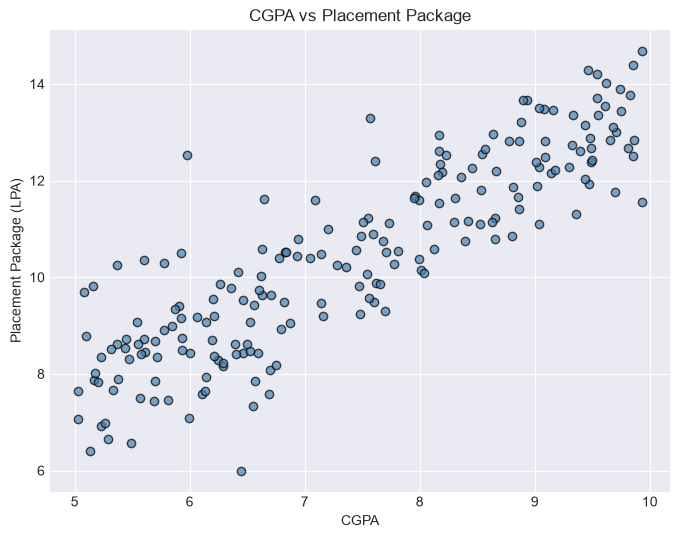

In [5]:
plt.figure(figsize=(8,6))
plt.scatter(df['CGPA'], df['Placement_Package_LPA'], color='steelblue', edgecolor='k', alpha=0.7)
plt.xlabel('CGPA')
plt.ylabel('Placement Package (LPA)')
plt.title('CGPA vs Placement Package')
plt.show()

## 3. Prepare Data (Train-Test Split)

In [6]:
X = df[['CGPA']]   # feature matrix (2D)
y = df['Placement_Package_LPA']   # target vector

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print('Train size:', X_train.shape[0])
print('Test size :', X_test.shape[0])

Train size: 160
Test size : 40


## 4. Train the Simple Linear Regression Model

In [7]:
model = LinearRegression()
model.fit(X_train, y_train)

print('Slope (m):', model.coef_[0])
print('Intercept (c):', model.intercept_)
print(f"Equation: Package = {model.coef_[0]:.3f} * CGPA + {model.intercept_:.3f}")

Slope (m): 1.2209150577579806
Intercept (c): 1.4100601083066824
Equation: Package = 1.221 * CGPA + 1.410


## 5. Predictions on Test Set

In [8]:
y_pred = model.predict(X_test)

results = pd.DataFrame({'Actual': y_test.values, 'Predicted': np.round(y_pred, 2)})
results.head(10)

,Actual,Predicted
0,9.81,10.53
1,10.50,8.64
2,10.08,11.23
3,8.71,8.97
4,7.65,7.55
5,11.30,12.84
6,11.55,13.53
7,10.75,11.65
8,12.53,11.46
9,11.63,11.56


## 6. Model Evaluation

In [9]:
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f'Mean Absolute Error (MAE): {mae:.3f}')
print(f'Mean Squared Error (MSE): {mse:.3f}')
print(f'Root Mean Squared Error (RMSE): {rmse:.3f}')
print(f'R² Score: {r2:.3f}')

Mean Absolute Error (MAE): 0.839
Mean Squared Error (MSE): 1.084
Root Mean Squared Error (RMSE): 1.041
R² Score: 0.677


## 7. Plot Regression Line (Best Fit Line)

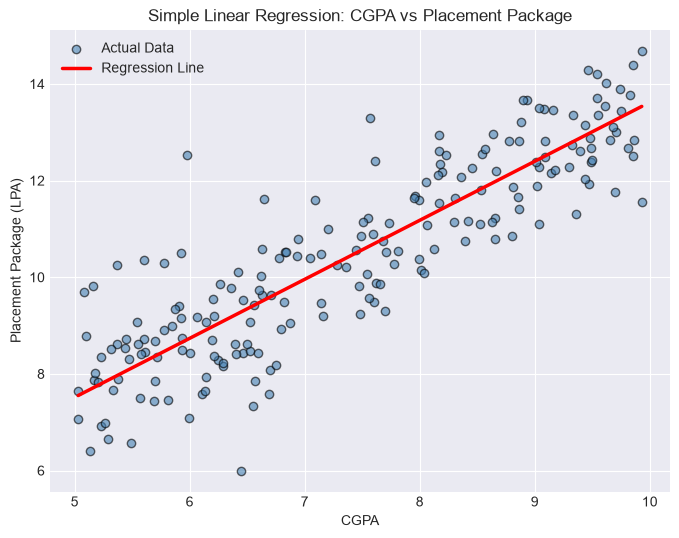

In [11]:
plt.figure(figsize=(8,6))

# scatter of full data
plt.scatter(df['CGPA'], df['Placement_Package_LPA'], color='steelblue', edgecolor='k', alpha=0.6, label='Actual Data')

# regression line across full range of CGPA
x_line = np.linspace(df['CGPA'].min(), df['CGPA'].max(), 100).reshape(-1,1)
y_line = model.predict(pd.DataFrame(x_line, columns=['CGPA']))
plt.plot(x_line, y_line, color='red', linewidth=2.5, label='Regression Line')

plt.xlabel('CGPA')
plt.ylabel('Placement Package (LPA)')
plt.title('Simple Linear Regression: CGPA vs Placement Package')
plt.legend()
plt.show()

## 8. Predict Package for a New CGPA

In [12]:
new_cgpa = 8.5
predicted_package = model.predict(pd.DataFrame([[new_cgpa]], columns=['CGPA']))
print(f'Predicted Placement Package for CGPA {new_cgpa}: {predicted_package[0]:.2f} LPA')

Predicted Placement Package for CGPA 8.5: 11.79 LPA
